In [178]:
## Importing libraries and creating a dataframe
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import hist
from numpy.ma.extras import average

df = pd.read_csv("flavors_of_cacao.csv")
df

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru
...,...,...,...,...,...,...,...,...,...
1790,Zotter,Peru,647,2011,70%,Austria,3.75,,Peru
1791,Zotter,Congo,749,2011,65%,Austria,3.00,Forastero,Congo
1792,Zotter,Kerala State,749,2011,65%,Austria,3.50,Forastero,India
1793,Zotter,Kerala State,781,2011,62%,Austria,3.25,,India


In [179]:
## Renaming columns and fixing values
df.columns = (["Company", "Origin", "REF", "ReviewYear", "CocoaPercentage", "CompanyLocation", "Rating", "BeanType", "BeanRegion"])
df["CocoaPercentage"] = df["CocoaPercentage"].str.replace("%", "").astype(float)
df['CompanyLocation'] = df['CompanyLocation'].replace('Amsterdam', 'Netherlands')
df.head()
df["BeanType"] = df["BeanType"].replace("\xa0", None)


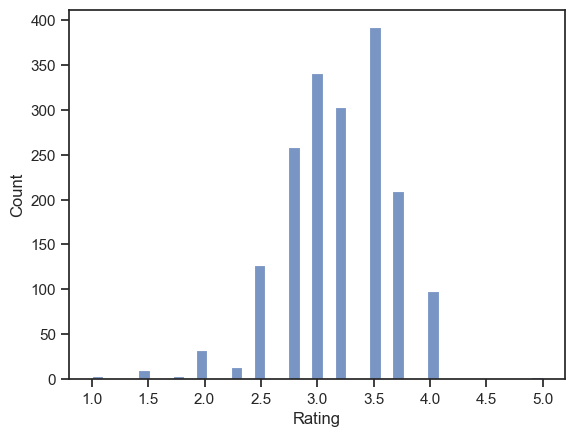

In [180]:
##Checking ratings distribution
RatingsPlot = sns.histplot(data =df, x = "Rating")

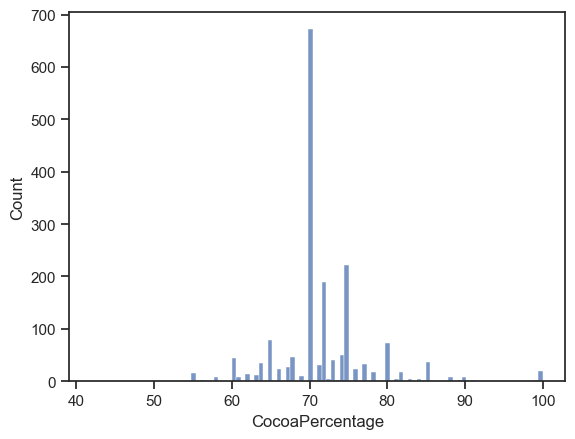

In [181]:
##Checking cocoa% distribution
CocoaPlot = sns.histplot(data =df, x = "CocoaPercentage", bins = 100)

Coeficcient of correlation between cocoa percentage and rating is: -0.165


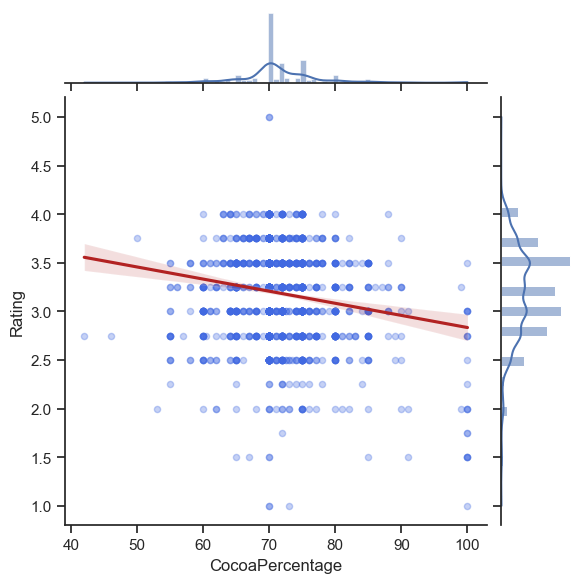

In [182]:
#Checking for correlation between cocoa% and rating
sns.set_theme(style = "ticks")

RatingCocoaPlot = sns.jointplot(data = df, x="CocoaPercentage", y="Rating", kind="reg", scatter_kws={"s":20,"alpha":0.3, "color":"royalblue"}, line_kws={"color" : "firebrick"})

correlation = df["CocoaPercentage"].corr(df["Rating"]).round(3)
print("Coeficcient of correlation between cocoa percentage and rating is:", correlation)

Ratings on graph are zoomed in 


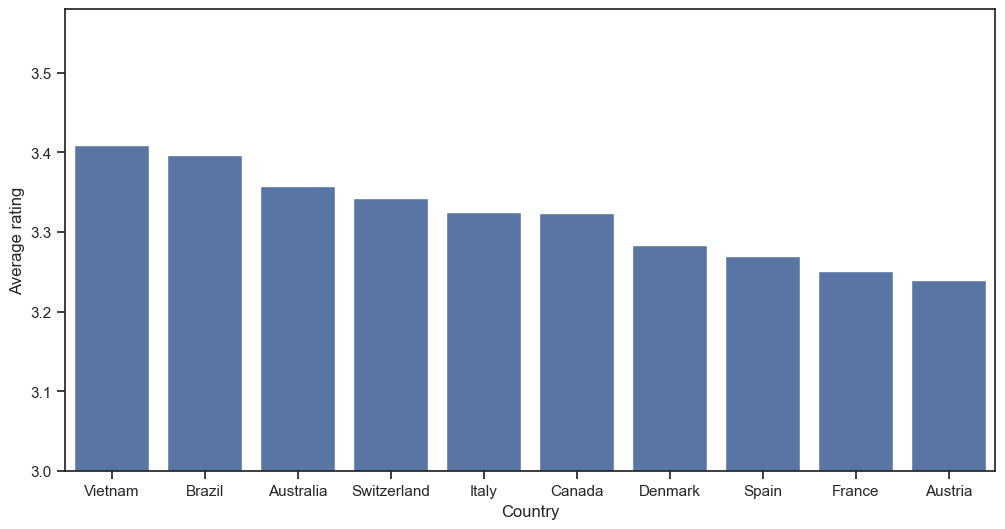

In [183]:
#Checking which country produces the best chocolate ( only with 10+ ratings)
plt.figure(figsize=(12, 6))
best_countries = df.groupby(["CompanyLocation"])["Rating"].agg(["count", "mean"])
best_countries = best_countries[best_countries["count"] > 10].sort_values("mean",ascending=0).head(10)
sns.barplot(best_countries, x = "CompanyLocation",y = "mean")
plt.ylabel("Average rating")
plt.xlabel("Country")
plt.ylim(3)
print("Ratings on graph are zoomed in ")

Ratings on graph are zoomed in 


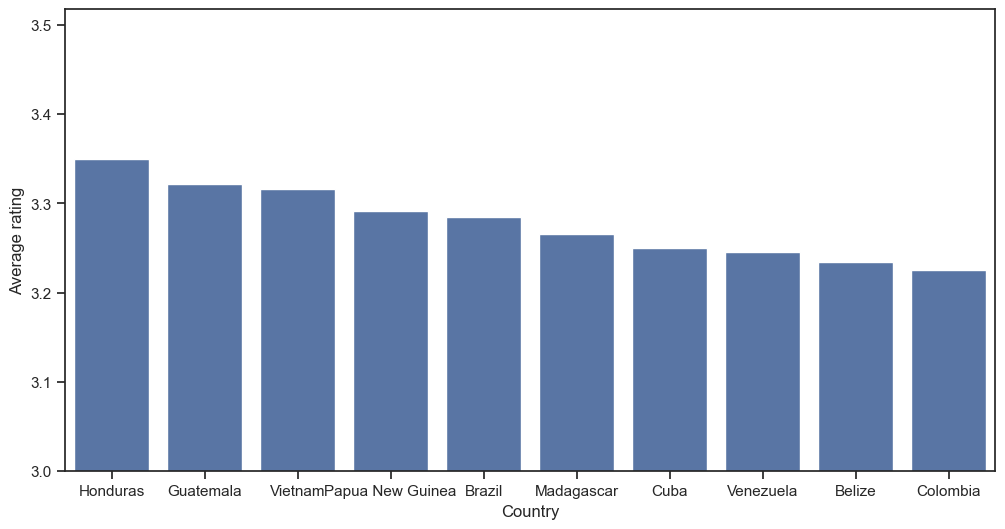

In [184]:
#Checking which region produces the best beans ( only with 10+ ratings)
plt.figure(figsize=(12, 6))
best_countries = df.groupby(["BeanRegion"])["Rating"].agg(["count", "mean"])
best_countries = best_countries[best_countries["count"] > 10].sort_values("mean",ascending=0).head(10)
sns.barplot(best_countries, x = "BeanRegion",y = "mean")
plt.ylabel("Average rating")
plt.xlabel("Country")
plt.ylim(3)
print("Ratings on graph are zoomed in ")

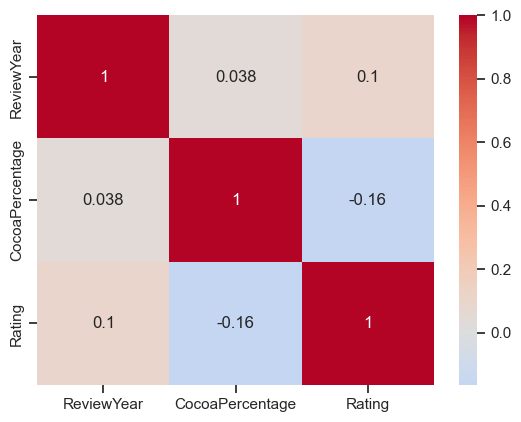

In [185]:
#drawing heatmap
correlation_matrix = df.drop("REF", axis = 1).corr(numeric_only=True)
heatmap = sns.heatmap(correlation_matrix, annot = True, cmap = "coolwarm", center = 0)


<Axes: xlabel='ReviewYear', ylabel='Rating'>

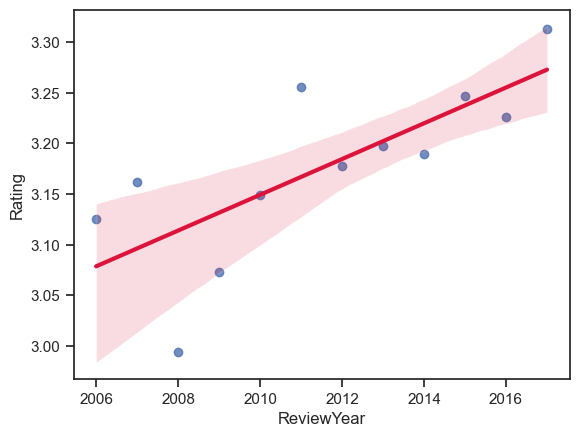

In [186]:
#Exploring deeper the correlation between year and rating
average_rating = df.groupby(["ReviewYear"])["Rating"].mean().reset_index()
sns.regplot(data = average_rating, x ="ReviewYear", y="Rating", line_kws={"color":"crimson", "lw":3})